# Exercise 1: Calculate pressure and fluid composition from melt and fluid inclusion data

<i>Authors</i>

<i>This exercise has been written for the 'Modelling the Behaviour of Volatiles in Magmas' workshop associated with Goldschmidt 2026 (Montréal, Québec, Canada) on Sunday 12th July 2026: https://kaylai.github.io/GS2026-volatiles-workshop/</i>



## 1.1 Introduction

In this exercise we will calculate pressures and fluid compositions from melt and fluid inclusion data from the 2018 Lower East Rift Zone eruption of Kı̄lauea (Wieser et al., 2021; DeVitre & Wieser, 2024) using the tools VESIcal (Iacovino et al., 2021), DiadFit (Wieser & DeVitre, 2024), VolFe (Hughes et al., 2025), and Thermobar (Wieser et al., 2022) through the VICTOR platform (Lev et al., 2025). For melt compositions, this is based on the fact that - for a particular major/minor element composition, temperature, and volatile content (partcuarly H<sub>2</sub>O and CO<sub>2</sub>) of the melt - there is a unique pressure at which the melt will be vapor saturated, called the pressure of vapor saturation, and the coexisting fluid will have a unique composition (see Hughes et al., 2024 for more details). This is often applied to melt inclusion (MI) data to calculate pressures of magma storage or submarine matrix glasse (MG) data to estimate eruption pressures, which in both cases can be converted to depths given overburden density. The fluid composition is sometimes used to estimate the composition of MI-hosted bubbles to reconstruct MI compositions at entrapment. Alternatively, for fluid compositions, the density of CO<sub>2</sub> in a fluid co-existing with a melt is highly pressure-sensitive. Hence, when combined with an entrapment temperature, the CO<sub>2</sub> density can be converted to pressure using an equation of state for CO<sub>2</sub> (see ??? for more details). This is often applied to fluid inclusion (FI) data to also calculate pressures of magma storage.

## 1.2 Python set-up
If you are running this notebook through your computer, you will need to install the relevant packages once on your computer, if you haven't already (remove the # before 'pip' on each line for packages you don't already have). 

If you are running this on the VICTOR platform, all packages are already installed and you can skip this step.

More information on VICTOR can be found at https://docs.victorproject.org/en/latest/index.html

In [1]:
# pip install VESIcal
# pip install DiadFit
# pip install VolFe
# pip install Thermobar
# pip install pandas # general use
# pip install matplotlib # for plotting

Then we need to import the Python packages to this notebook to run calculations. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf
import VESIcal as vc
import Thermobar as tb

c:\Users\erych\miniconda3\envs\volfe_prod\Lib\site-packages\VESIcal\calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below.

In [3]:
print('VolFe '+vf.__version__, ', VESIcal '+vc.__version__, ', Thermobar '+tb.__version__)

VolFe 1.0.2 , VESIcal 1.2.10 , Thermobar 1.0.60


## 1.3 Import data

Typically, you'll have a spreadsheet full of either melt or fluid inclusion analyses to process. In this case, we've created simplified csv files derived from the spreadsheets provided in Supplementary Materials of the original papers (i.e., some columns and rows have been deleted to make them easier to use).

<i>wieser2021_data_simple.csv</i> is derived from <i>Supplement_Wieser_et_al_G3.xlsx</i> from Wieser et al. (2021) combining data in the 'Melt_Inclusions' and 'Matrix_Glasses' sheets. Only the PEC-corrected data is included, as well as the bubble+glass value for CO<sub>2</sub>.

<i>??? Should we just H2O = 0.5 wt% H2O as in Wieser et al. (2021) ???</i>

<i>??? something about FI data ???</i>

In [4]:
MI = pd.read_csv("files/wieser2021_data_simple.csv")

In [5]:
# FI

We can plot the data to see how it looks - like the H<sub>2</sub>O and CO<sub>2</sub> content of melt inclusions and matrix glass.

Text(0, 0.5, 'CO2[m] (ppm)')

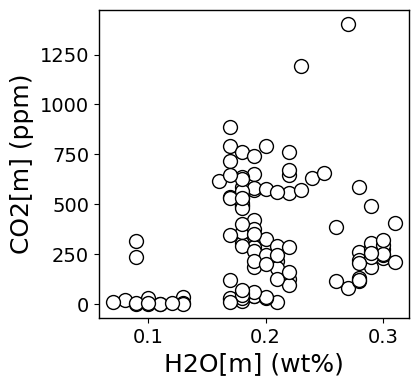

In [6]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))

df = MI

ax1.plot(df['H2O (wt%) (wt%, PEC-corr) MI'],
         df['Total CO2 (PEC-corrected) ppm'], 'ok', mfc='white')

ax1.set_xlabel('H2O[m] (wt%)')
ax1.set_ylabel('CO2[m] (ppm)')

## 1.4 Calculate temperature using Thermobar

A temperature is requied to calculate pressures and fluid compositions from MI/MG data. Thermobar has a huge variety of thermometers available to choose from. 

More information on Thermobar can be found at https://thermobar.readthedocs.io/en/latest/

Run the next cell to see the options available in Thermobar just for liquid-only thermometers.

In [7]:
help(tb.calculate_liq_only_temp)

Help on function calculate_liq_only_temp in module Thermobar.liquid_thermometers:

calculate_liq_only_temp(
    *,
    liq_comps,
    equationT,
    P=None,
    H2O_Liq=None,
    print=False
)
     Liquid-only thermometery. Returns a temperature in Kelvin.

    Parameters
     -------

     liq_comps: pandas.DataFrame
         liquid compositions with column headings SiO2_Liq, MgO_Liq etc.

     equationT: str
         If has _sat at the end, represents the saturation surface of that mineral.

         Equations from Putirka et al. (2016).
             | T_Put2016_eq3_amp_sat (saturation surface of amphibole)

         Equations from Putirka (2008) and older studies:

             | T_Put2008_eq13
             | T_Put2008_eq14
             | T_Put2008_eq15
             | T_Put2008_eq16
             | T_Put2008_eq34_cpx_sat
             | T_Put1999_cpx_sat
             * Following 3 thermometers are adaptations of olivine-liquid thermometers with  DMg calculated using Beattie 1993,
    

Following Wieser et al. (2021), we calculate the temperature using the MgO-liquid thermometer of Helz & Thornber (1987) implemented in Thermobar. 

Thermobar requires certain column names to recognise what each column contains - so first we'll need to rename the columns to be compatible with Thermobar. Thermobar also assumes the composition is in wt%, so anything that isn't would need to be converted. Then we can run the calculation and add the results to the original dataframe!

In [8]:
# renames column names to be compatible with Thermobar
MI_tb = MI.rename(columns = {"SiO2 (wt%, PEC-corr) MI":"SiO2_Liq","TiO2 (wt%, PEC-corr) MI":"TiO2_Liq","Al2O3 (wt%, PEC-corr) MI":"Al2O3_Liq","FeO (wt%, PEC-corr) MI":"FeOt_Liq","MnO (wt%, PEC-corr) MI":"MnO_Liq","MgO (wt%, PEC-corr) MI":"MgO_Liq","CaO (wt%, PEC-corr) MI":"CaO_Liq",
                                               "Na2O (wt%, PEC-corr) MI":"Na2O_Liq","K2O (wt%, PEC-corr) MI":"K2O_Liq","P2O5 (wt%, PEC-corr) MI":"P2O5_Liq","H2O (wt%) (wt%, PEC-corr) MI":"H2O_Liq"})

# calculate temperature in celcius (hence -273.15) using MgO-Lq thermometer of Helz & Thornber (1987) using Thermobar
T_C = tb.calculate_liq_only_temp(liq_comps=MI_tb, equationT="T_Helz1987_MgO")-273.15

# adds temperatures to original dataframe
MI.insert(1,"T_C",T_C)

We can plot the MgO content against the temperature to see the correlation.

Text(0, 0.5, 'T (C)')

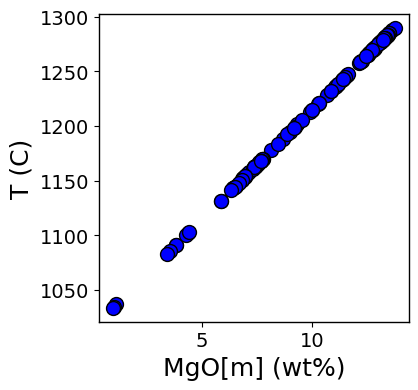

In [9]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))

df = MI

ax1.plot(df['MgO (wt%, PEC-corr) MI'],
         df['T_C'], 'ok', mfc='blue')

ax1.set_xlabel('MgO[m] (wt%)')
ax1.set_ylabel('T (C)')

## 1.5 Calculate pressure and fluid composition using VESIcal

We can now calculate the pressure of vapor saturation and fluid composition using VESIcal, which assumes the fluid and melt only contain oxidised C-O-H-bearing species (e.g., CO<sub>2</sub> and H<sub>2</sub>O). 

More information on VESIcal can be found at https://vesical.readthedocs.io/en/latest/

There are multiple model options available in VESIcal for the H<sub>2</sub>O and CO<sub>2</sub> solubility, which can be explored changing the 'model' option. Run the cell below to list the models available.

In [10]:
vc.get_model_names()

['ShishkinaIdealMixing',
 'Dixon',
 'IaconoMarziano',
 'Liu',
 'ShishkinaCarbon',
 'ShishkinaWater',
 'DixonCarbon',
 'DixonWater',
 'IaconoMarzianoCarbon',
 'IaconoMarzianoWater',
 'AllisonCarbon',
 'AllisonCarbon_sunset',
 'AllisonCarbon_sfvf',
 'AllisonCarbon_erebus',
 'AllisonCarbon_vesuvius',
 'AllisonCarbon_etna',
 'AllisonCarbon_stromboli',
 'MooreWater',
 'LiuWater',
 'LiuCarbon']

Here we'll use Iacono-Marziano et al. (2021) [IaconoMarziano]. <i>??? Can use MagmaSat if it'll be running on VICTOR ??? </i>

Note that how the melt composition is normalised is important for the results and different H<sub>2</sub>O-CO<sub>2</sub> models use different normalisation routines (further explanations can be found in Iacovino et al., 2021, and Wieser et al., 2021). IaconoMarziano uses the 'additionalvolatiles' normalisation routine, whereby the anhydrous melt composition is normalised to 100 wt%; CO<sub>2</sub> and H<sub>2</sub>O are added on top (i.e., the sum is greater than 100 wt%); and then everything is renormalised to 100 wt%.

In [11]:
# chooses model option and normalisation routine
# Iacono-Marziano et al. (2012)
model, normalisation = 'IaconoMarziano', 'additionalvolatiles'

Now we can run VESIcal using our chosen H<sub>2</sub>O-CO<sub>2</sub> model. As with Thermobar, VESIcal requires certain (but different) column headers to understand the input data. This is why we changed the column headers in the notebook rather than in the spreadsheet. Also, CO<sub>2</sub> needs to be in wt% not ppm, so we convert it. Then we use the <i>calculate_equilibrium_fluid_comp</i> function to calculate both pressure and fluid composition.

In [12]:
# renames column names to be compatible with VESIcal
MI_vc = MI.rename(columns = {"SiO2 (wt%, PEC-corr) MI":"SiO2","TiO2 (wt%, PEC-corr) MI":"TiO2","Al2O3 (wt%, PEC-corr) MI":"Al2O3","FeO (wt%, PEC-corr) MI":"FeOt","MnO (wt%, PEC-corr) MI":"MnO","MgO (wt%, PEC-corr) MI":"MgO","CaO (wt%, PEC-corr) MI":"CaO",
                                               "Na2O (wt%, PEC-corr) MI":"Na2O","K2O (wt%, PEC-corr) MI":"K2O","P2O5 (wt%, PEC-corr) MI":"P2O5","H2O (wt%) (wt%, PEC-corr) MI":"H2O"})

# converts CO2 from ppm to wt% and uses header compatible with VESIcal
MI_vc['CO2'] = MI_vc['Total CO2 (PEC-corrected) ppm']/10000.

# runs calculation with model and normalisation routine
MI_vc.to_csv('MI_vc.csv', index=True, header=True)
MI_vc_ = vc.BatchFile('MI_vc.csv')
norm_data = MI_vc_.get_data(normalization=normalisation)
fixed_norm_data = vc.BatchFile(filename=None, dataframe=norm_data)
results_vc = fixed_norm_data.calculate_equilibrium_fluid_comp(temperature='T_C',model=model)

c:\Users\erych\miniconda3\envs\volfe_prod\Lib\site-packages\VESIcal\batchfile.py:168: RuntimeWarning: No Label column given, so column 'Unnamed: 0' was chosen for you. To choose your own, set label='<column-name>'.
  data = self.try_set_index(data, label)
C:\Users\erych\AppData\Local\Temp\ipykernel_41500\2616657221.py:10: RuntimeWarning: Total iron column FeOt detected. This column will be treated as FeO. If Fe2O3 data are not given, Fe2O3 will be 0.0. In future, an option to calcualte FeO/Fe2O3 based on fO2 will be implemented.
  MI_vc_ = vc.BatchFile('MI_vc.csv')
c:\Users\erych\miniconda3\envs\volfe_prod\Lib\site-packages\VESIcal\batchfile.py:230: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate o

And we plot to see how the melt volatile content changes with the calculated pressure and what the fluid composition is doing as well!

Text(0.5, 0, 'CO2[f] (mol. frac.)')

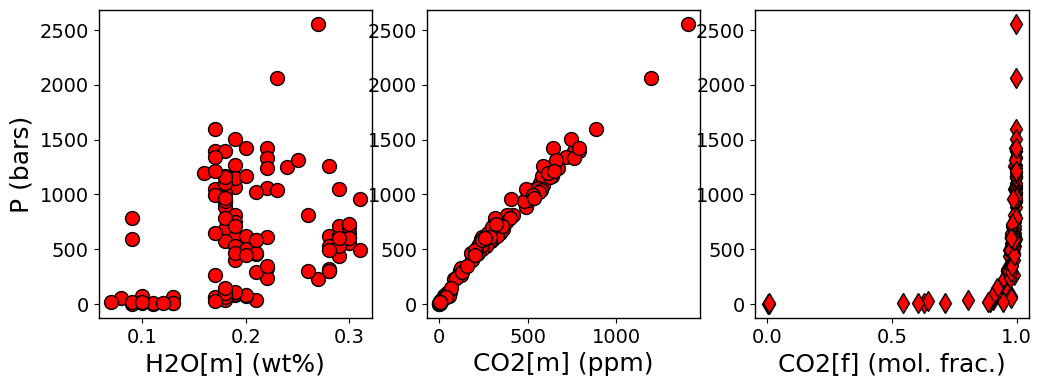

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))

df = results_vc

ax1.plot(df['H2O'],
         df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax2.plot(df['CO2']*10000,
         df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'],
         df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H2O[m] (wt%)')
ax2.set_xlabel('CO2[m] (ppm)')
ax3.set_xlabel('CO2[f] (mol. frac.)')

## 1.6 Calculate pressure and fluid composition using VolFe

We can also calculate the pressure of vapor saturation and fluid composition using VolFe, which assumes the fluid and melt contain a variety of reduced and oxidised C-O-H-S-bearing species. This needs additional information, such as some estimate of an oxygen fugacity related variable (e.g., fO2, deltaFMQ, deltaNNO, Fe3+/FeT, or S6+/ST). We'll use a value of deltaFMQ+0.2 for all MI and MG, which is within the range described in Wieser et al. (2021), but in other examples this can be specified for each composition individually.

More information on VolFe can be found at https://volfe.readthedocs.io/en/latest/

There are lots of different options available in VolFe. Similar to VESIcal, there are different H2O and CO2 solubility models, but there are also different sulfide and sulfate solubility models and relationships between Fe3+/FeT and fO2 to choose from. Run the cell below to see all the parameters that can be changed in VolFe.

In [14]:
help(vf.make_df_and_add_model_defaults)

Help on function make_df_and_add_model_defaults in module VolFe.model_dependent_variables:

make_df_and_add_model_defaults(models)
    Converts user-provided model configurations (e.g. ['carbon dioxide','MORB_Dixon95'],
    ['hydrogen sulfide','basaltic andesite'] into a structured pandas DataFrame,
    combined with default options for anything not specified.


    Parameters
    ----------
    models : list of [str, str]
        Each inner list contains two elements: the model type (str) and the
        user-specified option (str) for that model type.

    Returns
    -------
    pandas.DataFrame
        Index of 'type' and  column of 'option', containing the user-specified option or
        the default option if none is provided.


    Model Parameters and Options
    ----------------------------
    The following parameters can be overridden in models.


    ### Specifying species ###

    COH_species: Specifying what COH species are present in the melt and vapor.
        - 'yes_H2

Here we'll focus on the H2O, CO2, sulfide, and sulfate solubility options:

In [15]:
# H2O solubility model
help(vf.C_H2O)

Help on function C_H2O in module VolFe.model_dependent_variables:

C_H2O(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving H2O in the melt.

    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.), not normally used unless model option
        requires melt composition.

    models: pandas.DataFrame
        Minimum requirement is indexes of "Hspeciation" and "water" and column label of


In [16]:
# CO2 solubility model
help(vf.C_CO3)

Help on function C_CO3 in module VolFe.model_dependent_variables:

C_CO3(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving CO2 as CO2,T (all oxidised carbon, i.e., CO2mol
    and CO32-, as CO2,T) in the melt: C_CO2,T = xmCO2,T/fCO2 (mole fraction/bar)


    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.).

    models: pandas.DataFrame
        Minimum requirement is index of "carbon 

In [17]:
# sulfide solubility model
help(vf.C_S)

Help on function C_S in module VolFe.model_dependent_variables:

C_S(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving S in the melt as S2-: C_S = wmS2-*(fO2/fS2)^0.5
    (in ppmw and bar).


    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.)..

    models: pandas.DataFrame
        Minimum requirement is index of "sulfide" and column label of "option".

    Returns
    -------
    

In [18]:
# sulfate solubility model
help(vf.C_SO4)

Help on function C_SO4 in module VolFe.model_dependent_variables:

C_SO4(
    PT,
    melt_wf,
    models=                            option
type                              
COH_species     yes_H2_CO_CH4_melt
H2S_m                         True
species X                       Ar
Hspeciation                   none
fO2                       Kress91A
...                            ...
error                          0.1
print status                 False
output csv                    True
setup                        False
high precision               False

[78 rows x 1 columns]
)
    Solubility constant for disolving S6+ in the melt: C_SO4 = wmS6+(fS2*fO2^3)^-0.5
    (in ppmw and bar)


    Parameters
    ----------
    PT: dict
        Pressure (bars) as "P" and temperature ('C) as "T".

    melt_wf: dict
        Melt composition (SiO2, TiO2, etc.)..

    models: pandas.DataFrame
        Minimum requirement is index of "sulfate" and column label of "option".

    Returns
    -------
  

We'll choose to use water solubility model from Fig. S2 of Hughes et al. (2024); CO2 solubility model from eq. (7) from Dixon (1997); sulfide solubility model from eq. (10.34) of O'Neill (2021); and sulfate solubility model from eq. (12a) of O'Neill & Mavrogenes (2022) - everything else will use the default options in VolFe. All options used are outputted in the results.

In [19]:
# choose the options I want - everything else will use the default options
models_vf = [['water','Basalt_Hughes24'],['carbon dioxide','Basalt_Dixon97'],['sulfide','ONeill21dil'],['sulfate','ONeill22dil']]

# turn to dataframe with correct column headers and indexes    
models_vf = vf.make_df_and_add_model_defaults(models_vf)

VolFe also uses different column names...

In [20]:
MI_vf = MI.rename(columns = {'Sample Name':'Sample',"SiO2 (wt%, PEC-corr) MI":"SiO2","TiO2 (wt%, PEC-corr) MI":"TiO2","Al2O3 (wt%, PEC-corr) MI":"Al2O3","FeO (wt%, PEC-corr) MI":"FeOT","MnO (wt%, PEC-corr) MI":"MnO","MgO (wt%, PEC-corr) MI":"MgO","CaO (wt%, PEC-corr) MI":"CaO",
                                               "Na2O (wt%, PEC-corr) MI":"Na2O","K2O (wt%, PEC-corr) MI":"K2O","P2O5 (wt%, PEC-corr) MI":"P2O5","H2O (wt%) (wt%, PEC-corr) MI":"H2O", "Total CO2 (PEC-corrected) ppm":'CO2ppm'})

In [21]:
MI_vf['DFMQ'] = 0.20
MI_vf['STppm'] = 1000.

And then we run the calculations...

In [22]:
# runs the calculation
results_vf = vf.calc_Pvsat(MI_vf)

... and compare them to the VESIcal results:

Text(0.5, 0, 'SO2/CO2[f] (mole frac.)')

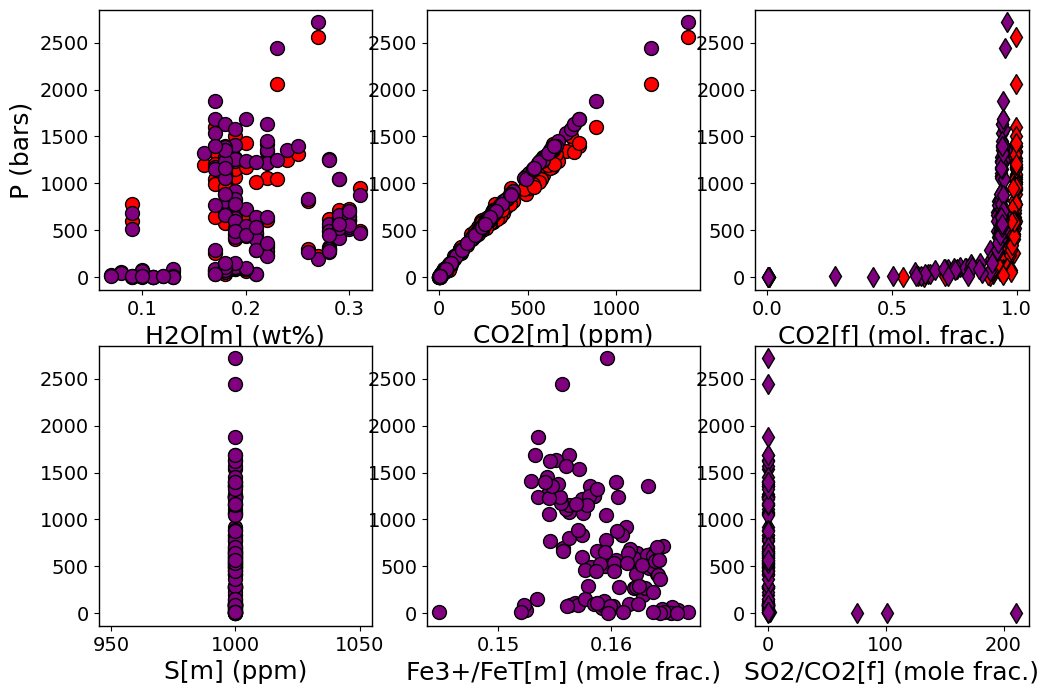

In [23]:
fig, ((ax1, ax2, ax3),(ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12,8))

df = results_vc
ax1.plot(df['H2O'],
         df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax2.plot(df['CO2']*10000,
         df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'],
         df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

df = results_vf
ax1.plot(df['H2OT-eq_wtpc'],
         df['P_bar'], 'ok', mfc='purple')
ax2.plot(df['CO2T-eq_ppmw'],
         df['P_bar'], 'ok', mfc='purple')
ax3.plot(df['xgCO2_mf'],
         df['P_bar'], 'dk', mfc='purple')
ax4.plot(df['ST_ppmw'],
         df['P_bar'], 'ok', mfc='purple')
ax5.plot(df['Fe3+/FeT'],
         df['P_bar'], 'ok', mfc='purple')
ax6.plot(df['xgSO2_mf']/df['xgCO2_mf'],
         df['P_bar'], 'dk', mfc='purple')

ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H2O[m] (wt%)')
ax2.set_xlabel('CO2[m] (ppm)')
ax3.set_xlabel('CO2[f] (mol. frac.)')
ax4.set_xlabel('S[m] (ppm)')
ax5.set_xlabel('Fe3+/FeT[m] (mole frac.)')
ax6.set_xlabel('SO2/CO2[f] (mole frac.)')

## FLUID INCLUSION PART ###

## 1.X Describing and citing calculations

Here is an example of how you might describe and cite the calculations presented here - including this notebook in Supplementary Material would ensure the calculations are reproduceable!

<i>All calculations were performed using the VICTOR platform (Lev et al., 2025). Melt inclusion data is from Wieser et al. (2021) and the fluid inclusion data from DiVitre & Wieser (2024). Temperature was calculated using the MgO-liquid thermometer from Helz & Thornber (1987) implemented in Thermobar (v1.0.60; Wieser et al., 2022). Pressure and fluid composition for melt inclusions were calculated using the model of Iacono-Marziano et al. (2012) implemented in VESIcal (v1.2.10) and models shown in Table 1 implemented in VolFe (v1.0.2; Hughes et al., 2025). SOMETHING FOR FI.</i>

Table 1. Model options used in VolFe calculations.
| Model dependent variable | Reference |
|---|---|
| O2 fugacity coefficient | Shi and Saxena (1992) |
| CO fugacity coefficient | Shi and Saxena (1992) |
| H2 fugacity coefficient | Shaw and Wones (1964) |
| S2 fugacity coefficient | Shi and Saxena (1992) |
| CO2 fugacity coefficient | Shi and Saxena (1992) |
| H2O fugacity coefficient | Eq. (4, 6: T > 673 K, A1, A2, A3) and Table 1 in Holland and Powell (1991) | 
| SO2 fugacity coefficient | Shi and Saxena (1992) as modified in Fig. S1 of Hughes et al. (2022) |
| CH4 fugacity coefficient | Shi and Saxena (1992) |
| H2S fugacity coefficient | Shi and Saxena (1992) as modified in Fig. S1 of Hughes et al. (2024) |
| OCS fugacity coefficient | Shi and Saxena (1992) |
| CO2 equilibrium constant | Reaction (c) in Table 1 of Ohmoto and Kerrick (1977) |
| H2O equilibrium constant | Reaction (d) in Table 1 of Ohmoto and Kerrick (1977) |
| SO2 equilibrium constant | Reaction (f) in Table 1 of Ohmoto and Kerrick (1977) |
| CH4 equilibrium constant | Reaction (e) in Table 1 of Ohmoto and Kerrick (1977) |
| H2S equilibrium constant | Reaction (h) in Table 1 of Ohmoto and Kerrick (1977) |
| OCS equilibrium constant | Eq. (8) in Moussallam et al. (2019) |
| H2OT solubility function | Fig. S2 in Hughes et al. (2024) |
| CO2,T solubility function | Eq. (7) in Dixon (1997) |
| H2,mol solubility function | Table S4 in Hughes et al. (2024) |
| COmol solubility function | Table S4 in Hughes et al. (2024) |
| CH4,mol solubility function | Eq. (7a) from Ardia et al. (2013) |
| *S2- solubility function | Eq. (10.43) from O’Neill (2021) (including the effect of H2O dilution) |
| SO42- solubility function | Eq. (12a) from O’Neill and Mavrogenes (2022) (including the effect of H2O dilution) |
| H2Smol solubility function | Fig. S6 in Hughes et al. (2024) |
| CO2,T equilibrium constant | All CO32- as basalt |
| Fe3+/FeT | Eq. (A-5, 6) from Kress and Carmichael (1991) |
| FMQ buffer | Frost (1991) |


## 1.XReferences

Ardia et al. (2013)

DeVitre, C.L. and Wieser, P.E., 2024. Reliability of Raman analyses of CO2-rich fluid inclusions as a geobarometer at Kīlauea. Geochemical perspectives letters, 29. https://doi.org/10.7185/geochemlet.2404

Dixon 1997

Frost (1991)

Helz & Thornber 1987

Hughes et al. (2022)

Hughes et al., 2024

Hughes, E.C., Liggins, P., Wieser, P. and Stolper, E.M., 2024. VolFe: an open-source Python package for calculating melt-vapor equilibria including silicate melt, carbon, hydrogen, sulfur, and noble gases. Volcanica, 8(2), pp. 457-481. https://doi.org/10.30909/vol/imvc1781

Holland and Powell (1991)

Iacano

Iacovino, K., Matthews, S., Wieser, P.E., Moore, G.M. and Bégué, F., 2021. VESIcal Part I: An open‐source thermodynamic model engine for mixed volatile (H2O‐CO2) solubility in silicate melts. Earth and Space Science, 8(11), p.e2020EA001584. https://doi.org/10.1029/2020EA001584

Kress and Carmichael (1991)

Lev et al. 2025

Moussallam et al. (2019)

Ohmoto and Kerrick (1977)

O'Neill 2021

O'Neill & Mavrogenes 2022

Shaw and Wones (1964)

Shi and Saxena (1992)

Wieser, P.E., Lamadrid, H., Maclennan, J., Edmonds, M., Matthews, S., Iacovino, K., Jenner, F.E., Gansecki, C., Trusdell, F., Lee, R.L. and Ilyinskaya, E., 2021. Reconstructing magma storage depths for the 2018 Kı̄lauean eruption from melt inclusion CO2 contents: the importance of vapor bubbles. Geochemistry, Geophysics, Geosystems, 22(2), p.e2020GC009364. https://doi.org/10.1029/2020GC009364

Wieser vesical 2021

Wieser, P., Petrelli, M., Lubbers, J., Wieser, E., Ozaydin, S., Kent, A. and Till, C. (2022) “Thermobar: An open-source Python3 tool for thermobarometry and hygrometry”, Volcanica, 5(2), pp. 349–384. https://doi.org/10.30909/vol.05.02.349384

Wieser, P.E. and DeVitre, C., 2024. DiadFit: an open-source Python3 tool for peak fitting of Raman data from silicate melts and CO2 fluids. Volcanica, 7(1), pp.335-359. https://doi.org/10.30909/vol.07.01.335359 





